## Contents <a id='cont'></a>
- [1. Introduction](#introduction)
- [2. Modeling the Transmon Qubit and Microwave Pulses](#model)
- [3. Solving for time-evolution with the RK78 method](#solve)
- [4. Simulation and Results](#sim)
- [5. Conclusions](#conc)

*Note: Throughout this notebook, $\hbar = 1$.*


# <a id='introduction'></a>[1&nbsp;&nbsp;&nbsp;Introduction](#cont)

To make a quantum computer reliable and achieve the best possible performance, all layers of the quantum computing stack must be developed together. One crucial area of research in quantum computing is quantum optimal control, which focuses on controlling quantum devices as accurately as possible. The specific tasks of quantum control depend on the quantum computing architecture. For superconducting qubits, quantum control concerns how the state of qubits can be manipulated using microwave pulses – in other words, how different gates can be applied to produce deterministic calculations through the combined state of multiple qubits. These calculations open up new computational possibilities for molecular simulations, financial optimisation, and the discovery of new physics.

In this notebook, we investigate a common task in quantum optimal control: finding an optimal gate to implement a 0-to-1 transition, also known as an X gate, or a $\pi$-gate when the qubit is visualised on the Bloch sphere. We compare three different pulse types, a rectangular pulse, a Gaussian pulse, and a Gaussian DRAG pulse, to determine which performs best on a transmon qubit.

To compare the pulses, the higher-energy levels of the transmon qubit are included in the simulation so that leakage (population transfer to non-computational states) into these states can be taken into account. When evaluating an optimal pulse, we consider two factors. First, we investigate how well a gate can be implemented when the pulse parameters are fully optimized. Second, we examine how the pulse performs when there are slight deviations from the optimal parameters, i.e., the robustness of the pulse against calibration errors and noise. These two factors are investigated and compared throughout this notebook to provide a final assessment of pulse quality.

# <a id='model'></a>[2. &nbsp;&nbsp;&nbsp;Modeling the Transmon Qubit and Microwave Pulses:](#cont)

### The transmon qubit

The transmon qubit [1] is the most common type of superconducting qubit. It is an anharmonic oscillator, where the two lowest energy states, the ground state $|0\rangle$, and the first excited state  $|1\rangle$, are utilized for computation. The anharmonicity is what makes it possible to address only the $|0\rangle \leftrightarrow |1\rangle$ transition without simultaneously driving transitions to higher levels of the qubit. The transmon can be modeled by the Hamiltonian 
$$
H_T = 4E_C(\hat{n} + n_g)^2 + E_J \text{cos}\hat{\phi},
$$

where $E_C$ is the charging energy and $E_J$ is the Josephson energy, both being fixed variables after fabrication of the qubit. $n_g$ is the offset charge, which can be set to zero during the computation as it does not affect the result. The two operators $\hat{n}$ and $\hat{\phi}$ in the Hamiltonian are the charge operator and the phase operator respectively. 

During the computation, a basis for the calculation must be specified. A typical choice is the charge basis, $|n\rangle$, for n $\in \Z$. Charge and phase operators are conjugate variables in quantum mechanics, related by $[\hat{\phi}, \hat{n}] = i$. This leads to $e^{i \hat{\phi}}$ description in charge basis as $$e^{i \hat{\phi}} = |n \rangle \langle n-1 |$$ and after decomposing the cosine into exponentials, the full expression for the transmon Hamiltonian in the charge basis $$
H = 4E_C \sum_n|n\rangle \langle n | + \frac{E_J}{2} \sum_n(|n \rangle \langle n-1 | + |n-1 \rangle \langle n |).$$

To get the computational states of the transmon, we diagonalize the hamiltonian. The eigenvalues $E_i$ for $i \in \Z_+$ are the energy levels, and the eigenvectors $|i\rangle$ for $i \in \Z_+$ are the corresponding energy states. 

### Driving the transmon


With microwave pulses, transitions can be driven between different energy states of the transmon. A qubit coupled to an electric field obtains an additional term for its Hamiltonian of the form $H_d = G \Omega(t)\text{cos}(\omega_d t)$, where $G = \sum_{i,j} \langle i | \hat{n} | j\rangle |i\rangle\langle j|$ is the coupling matrix containing the coupling strengths betwen transmon states, $\omega_d$ is the drive frequency, and $\Omega(t)$ is the pulse envelope. Setting $\omega_d = \omega_{01}$ makes the drive resonant with the $|0\rangle \to |1\rangle$ transition. The driven transmon Hamiltonian takes the form

$$
H(t) = H_T + H_{d} = 4E_C \sum_n|n\rangle \langle n | + \frac{E_J}{2} \sum_n(|n \rangle \langle n-1 | + |n-1 \rangle \langle n |) + G \Omega(t)\text{cos}(\omega_d t).
$$

The charge basis is infinite, but for practical reasons it is truncated at some maximum charge N. For sufficiently large N, this approximation will not impact the system significantly. After computing the transmon energy states for 2*N + 1 levels, we truncate it to keep the most relevant states to allow for an efficient simulation. Since we are simulation 0-1 transitions, a sufficient cutoff is at energy level 4, as higher states do not significantly contribute to the leakage by the qubit. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate 

In [2]:
def transmon(Ej = 10e9, Ec = 0.3e9, N=100):
    """
    Calculate the transmon Hamiltonian, energy eigenvalues, and coupling matrix.

    The Hamiltonian is constructed in the charge basis using a truncated
    Hilbert space of charge states n = -N, ..., N.

    Parameters
    ----------
    Ej : float, optional
        Josephson energy in Hz.
    Ec : float, optional
        Charging energy in Hz.
    N : int, optional
        Charge basis truncation parameter.

    Returns
    -------
    tuple[np.ndarray, np.ndarray, np.ndarray]
        Hamiltonian matrix, energy eigenvalues, and coupling matrix.
    """
    n = np.diag(np.arange(-N, N+1))
    Hc = 4*Ec*n**2
    Hj = -Ej/2*(np.diag([1]*(2*N), 1)+ np.diag([1]*(2*N), -1))
    H = Hc + Hj
    En, eig_c = np.linalg.eigh(H)
    H0 = np.diag(En)
    G = eig_c.conj().T @ n @ eig_c
    return H0, En, G

H0, energy_levels, G = transmon()
K=4 # how many states we keep in the transmon simulation
Es = energy_levels[:K]
Htransmon = H0[:K,:K]
G4 = G[:K, :K]

### The microwave pulse

The pulse consists of a carrier at frequency $\omega_d$ and a slowly-varying envelope $\Omega(t)$ that shapes the amplitude over time. The carrier drives the oscillation at the qubit transition frequency, while the envelope controls the total rotation angle — here we aim for a $\pi$-pulse. We compare three envelope shapes:

- **Rectangular**: Constant amplitude within $[0, T]$, zero outside. Simple, but the abrupt edges introduce spectral broadening that can drive off-resonant transitions to $|2\rangle$.
  $$\Omega(t) = \begin{cases} A & 0 \le t \le T \\ 0 & \text{otherwise} \end{cases}$$

- **Gaussian**: Smooth bell-shaped envelope centered at $t_0$ with standard deviation $\sigma = T/8$, that was chosen so the pulse decays to negligible amplitude at the window edges (at 4 $\sigma$ from center). The smooth edges narrow the frequency spectrum compared to the rectangular pulse.
  $$\Omega(t) = A\exp\!\left(-\frac{(t-t_0)^2}{2\sigma^2}\right)$$

- **Gaussian DRAG** (Derivative Removal via Adiabatic Gate) [2]: A Gaussian with an added imaginary component proportional to its time-derivative. The imaginary term creates a frequency shift that cancels the drive on the $|1\rangle \to |2\rangle$ transition and therefore suppresses leakage to the second excited state. The DRAG coefficient is set to $\beta = -1/\delta$, where $\delta = \omega_{01} - \omega_{12}$ is the anharmonicity.
  $$\Omega(t) = A\exp\!\left(-\frac{(t-t_0)^2}{2\sigma^2}\right)\!\left[1 - i\beta\frac{(t-t_0)}{\sigma^2}\right]$$

All envelopes are normalized to the same total energy so that comparisons reflect pulse shape only, not energy differences.

In [5]:
def rect(t, duration, T):
    """
    Rectangular pulse envelope centered in the simulation window.

    Parameters
    ----------
    t : float
        Time in seconds.
    duration : float
        Total simulation duration in seconds.
    T : float
        Pulse width in seconds.

    Returns
    -------
    float
        Pulse amplitude at time t.
    """
    t_start = (duration - T) / 2
    t_end = t_start + T

    return 1.0 if t_start <= t <= t_end else 0.0


def make_gaussian(duration, T, sigma, area_normalized=True):
    """
    Create a Gaussian pulse envelope.

    Parameters
    ----------
    duration : float
        Total simulation duration in seconds.
    T : float
        Pulse width in seconds.
    sigma : float
        Gaussian standard deviation in seconds.
    area_normalized : bool, optional
        If True, normalize the pulse area to match the rectangular pulse.

    Returns
    -------
    function
        Gaussian pulse envelope function evaluated as gauss(t).
    """
    t_start = (duration - T) / 2
    t_end = t_start + T
    t_center = duration / 2

    def g_full(t):
        return np.exp(-(t - t_center)**2 / (2 * sigma**2))
    g0 = g_full(t_start)
    def g_cut(t):
        if t < t_start or t > t_end:
            return 0.0
        return g_full(t) - g0
    
    if area_normalized:
        integral, _ = integrate.quad(g_cut, t_start, t_end)
        norm = T / integral
    else:
        norm = 1.0

    def env(t):
        return norm * g_cut(t)
    return env


def make_gaussian_drag(duration, T, sigma, beta, area_normalized=True):
    """
    Create a Gaussian DRAG pulse envelope.

    Parameters
    ----------
    duration : float
        Total simulation duration in seconds.
    T : float
        Pulse width in seconds.
    sigma : float
        Gaussian standard deviation in seconds.
    beta : float
        DRAG correction coefficient.
    area_normalized : bool, optional
        If True, normalize the pulse area to match the rectangular pulse.

    Returns
    -------
    function
        Complex DRAG pulse envelope function evaluated as gauss_drag(t).
    """

    t_center = duration / 2

    gaussian_env = make_gaussian(duration=duration, T=T, sigma=sigma, area_normalized=area_normalized)
    
    t_start = (duration - T) / 2
    t_end = t_start + T
    
    def env(t):
        if t < t_start or t > t_end:
            return 0.0 + 0.0j
        
        g = gaussian_env(t)
        
        # derivative term
        drag_term = -(t - t_center) / sigma**2 * g
        
        return g + 1j * beta * drag_term
    
    return env

### Visualizing the envelopes

The real and imaginary components of each envelope are shown below. The rectangular and Gaussian pulses are purely real, but the DRAG pulse has an additional imaginary component (exaggerated here for visibility — in practice it is much smaller than the real part). All envelopes are normalized to the same energy, so the Gaussian-type pulses have a higher peak amplitude to compensate for their narrower shape. Amplitudes are shown in normalized units, but during the actual drive they are rescaled to the MHz range (energy is expressed in frequency units since $\hbar = 1$).


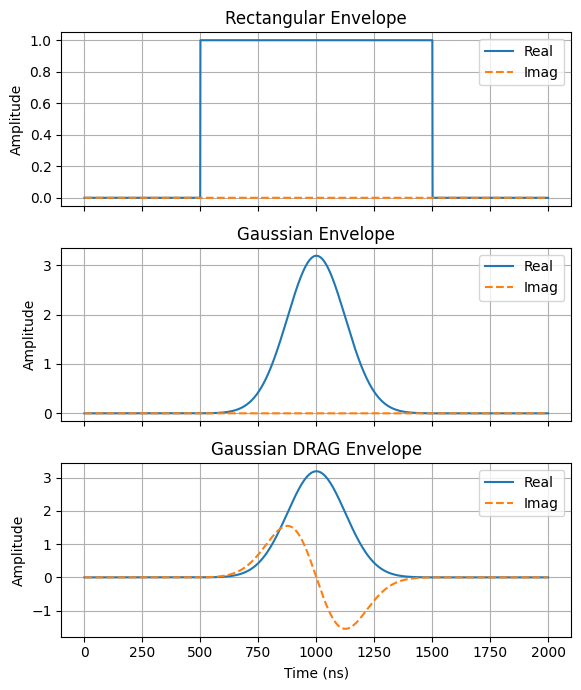

In [6]:
# simulation window
duration = 2000e-9

# pulse width
T = 1000e-9

# time step
dt = 1e-9

pulse_start = (duration - T) / 2
pulse_end = pulse_start + T

sigma=T/8  # 4 standard deviations from center to edge that balances truncation error and pulse narrowness
beta = 1e-7 # make DRAG coeficient very large to visualise it. Note: Much smaller in practise

gauss = make_gaussian(duration=duration, T=T, sigma=sigma, area_normalized=True)
drag = make_gaussian_drag(duration=duration, T=T, sigma=sigma, beta=beta, area_normalized=True )

ts = np.arange(0, duration, dt)

rect_vals = np.array([rect(t, duration, T) for t in ts], dtype=complex)
gauss_vals = np.array([gauss(t) for t in ts], dtype=complex)
drag_vals = np.array([drag(t) for t in ts], dtype=complex)

fig, axes = plt.subplots(3, 1, figsize=(6, 7), sharex=True)

def add_plot_info(ax, title):
    ymax = ax.get_ylim()[1]
    ax.set_title(title)
    ax.set_ylabel("Amplitude")
    ax.grid()
    ax.legend()

# Rectangular
axes[0].plot(ts * 1e9, rect_vals.real, label="Real")
axes[0].plot(ts * 1e9, rect_vals.imag, "--", label="Imag")
add_plot_info(axes[0], "Rectangular Envelope")

# Gaussian
axes[1].plot(ts * 1e9, gauss_vals.real, label="Real")
axes[1].plot(ts * 1e9, gauss_vals.imag, "--", label="Imag")
add_plot_info(axes[1], "Gaussian Envelope")

# DRAG
axes[2].plot(ts * 1e9, drag_vals.real, label="Real")
axes[2].plot(ts * 1e9, drag_vals.imag, "--", label="Imag")
add_plot_info(axes[2], "Gaussian DRAG Envelope")

axes[2].set_xlabel("Time (ns)")

plt.tight_layout()
plt.show()

# <a id='solve'></a>[3. &nbsp;&nbsp;&nbsp;Implementing time evolution solver with the Runge-Kutta 7(8) method:](#solve)


To obtain the final state of the qubit after the application of a microwave pulse, the time evolution of the quantum state must be solved. The dynamics are governed by the time-dependent Schrödinger equation (*Recall: we work in units where* $\hbar = 1$):

$$
i \frac{d}{dt} |\psi(t)\rangle = H(t)|\psi(t)\rangle,
$$

where

$$
H(t) = H_T + H_d(t)
$$

is the driven transmon Hamiltonian defined in the previous section. The system is initialized in the ground state,

$$
|\psi(t=0)\rangle = |0\rangle.
$$

Quantum dynamics simulations require high numerical precision in order to accurately determine the final state populations. For this reason, a high-order Runge–Kutta method [3] is utilized. In this project, the Runge–Kutta 7(8) (RK78) method is applied.

The RK78 method solves ordinary differential equations of the form

$$
\frac{dy}{dt} = f(t,y).
$$

Comparing this with the Schrödinger equation, we identify

$$
y(t) = |\psi(t)\rangle,
$$

and

$$
f(t,y) = -i H(t)|\psi(t)\rangle.
$$

The RK78 method is Runge–Kutta method consisting of 7th and 8th-order solutions. The difference between these solutions provides an estimate of the local error, which enables the use of an adaptive step size h during the simulation. An adaptive h improves computational efficiency while keeping a the error under control.

The state update from $y_i$ to $y_{i+1}$ is given by

$$
y_{i+1} =
y_i
+
h\left(
\frac{41}{840}k_1
+
\frac{34}{105}k_6
+
\frac{9}{35}k_7
+
\frac{9}{35}k_8
+
\frac{9}{280}k_9
+
\frac{9}{280}k_{10}
+
\frac{41}{840}k_{11}
\right),
$$

with

$$
x_{i+1} = x_i + h.
$$

The intermediate slopes $k_n$ are computed using Taylor-expanded estimates of the solution at intermediate points. The working equation are [4]:

| Equation | Expression |
|---|---|
| $k_1$ | $f(x_i,\; y_i)$ |
| $k_2$ | $f\left(x_i+\frac{2h}{27},\; y_i+\frac{2h}{27}k_1\right)$ |
| $k_3$ | $f\left(x_i+\frac{h}{9},\; y_i+\frac{h}{36}(k_1+3k_2)\right)$ |
| $k_4$ | $f\left(x_i+\frac{h}{6},\; y_i+\frac{h}{24}(k_1+3k_3)\right)$ |
| $k_5$ | $f\left(x_i+\frac{5h}{12},\; y_i+\frac{h}{48}(20k_1-75k_3+75k_4)\right)$ |
| $k_6$ | $f\left(x_i+\frac{h}{2},\; y_i+\frac{h}{20}(k_1+5k_4+4k_5)\right)$ |
| $k_7$ | $f\left(x_i+\frac{5h}{6},\; y_i+\frac{h}{108}(-25k_1+125k_4-260k_5+250k_6)\right)$ |
| $k_8$ | $f\left(x_i+\frac{h}{6},\; y_i+h\left(\frac{31}{300}k_1+\frac{61}{225}k_5-\frac{2}{9}k_6+\frac{13}{900}k_7\right)\right)$ |
| $k_9$ | $f\left(x_i+\frac{2h}{3},\; y_i+h\left(2k_1-\frac{53}{6}k_4+\frac{704}{45}k_5-\frac{107}{9}k_6+\frac{67}{90}k_7+3k_8\right)\right)$ |
| $k_{10}$ | $f\left(x_i+\frac{h}{3},\; y_i+h\left(-\frac{91}{108}k_1+\frac{23}{108}k_4-\frac{976}{135}k_5+\frac{311}{54}k_6-\frac{19}{60}k_7+\frac{17}{6}k_8-\frac{1}{12}k_9\right)\right)$ |
| $k_{11}$ | $f\left(x_i+h,\; y_i+h\left(\frac{2383}{4100}k_1-\frac{341}{164}k_4+\frac{4496}{1025}k_5-\frac{301}{82}k_6+\frac{2133}{4100}k_7+\frac{45}{82}k_8+\frac{45}{164}k_9+\frac{18}{41}k_{10}\right)\right)$ |
| $k_{12}$ | $f\left(x_i,\; y_i+h\left(\frac{3}{205}k_1-\frac{6}{41}k_6-\frac{3}{205}k_7-\frac{3}{41}k_8+\frac{3}{41}k_9+\frac{6}{41}k_{10}\right)\right)$ |
| $k_{13}$ | $f\left(x_i+h,\; y_i+h\left(-\frac{1777}{4100}k_1-\frac{341}{164}k_4+\frac{4496}{1025}k_5-\frac{289}{82}k_6+\frac{2193}{4100}k_7+\frac{51}{82}k_8+\frac{33}{164}k_9+\frac{12}{41}k_{10}+k_{12}\right)\right)$ |

 If the estimated error exceeds a defined tolerance, the step is rejected and recomputed using a smaller step size. Additionally, if the error is sufficiently small, the step size is increased in order to improve computational efficiency.

The step size is updated according to

$$
h \rightarrow 0.9 \cdot h \cdot \min\left(2.0,\;\max\left(0.2,\;\left(\frac{\text{tol}}{\text{error}}\right)^{1/8}\right)\right).
$$

The key quantity controlling the update is the ratio

$$
\frac{\text{tol}}{\text{error}},
$$

which determines whether the step size should increase or decrease. The minimum and maximum functions constrain the change in step size to the interval

$$
0.2h \leq h_{\mathrm{new}} \leq 2h.
$$

This prevents too drastic changes in the integration step.


In [7]:
def solve_ode_rk78(start, end, initial_state, f, error_tolerance):
    """
    Solve an ordinary differential equation using adaptive RK78 method.

    Parameters
    ----------
    start : float
        Initial time.
    end : float
        Final time.
    initial_state : np.ndarray
        Initial state vector.
    f : function
        Function defining the ODE dy/dt = f(t, y).
    error_tolerance : float
        Adaptive integration error tolerance.

    Returns
    -------
    tuple[list, list]
        Numerical solution and corresponding time points.
    """
    
    t = start
    psi = initial_state
    state_evolution = [psi]
    times = [start]
    h = (end - start) / 1000

    while t < end:
            h = min(h, end - t)
            k1 = f(t, psi)
            k2 = f(t + 2*h/27, psi + 2*h*k1/27)
            k3 = f(t + h/9, psi + h/36*(k1 + 3*k2))
            k4 = f(t + h/6, psi + h/24*(k1 + 3*k3))
            k5 = f(t + 5*h/12, psi + h/48*(20*k1 - 75*k3 + 75*k4))
            k6 = f(t + h/2, psi + h/20*(k1 + 5*k4 + 4*k5))
            k7 = f(t + 5*h/6, psi + h/108*(-25*k1 + 125*k4 - 260*k5 + 250*k6))
            k8 = f(t + h/6, psi + h*(31/300*k1 + 61/225*k5 - 2/9*k6 + 13/900*k7))
            k9 = f(t + 2*h/3, psi + h*(2*k1 - 53/6*k4 + 704/45*k5 - 107/9*k6 + 67/90*k7 + 3*k8))
            k10 = f(t + h/3, psi + h*(-91/108*k1 + 23/108*k4 - 976/135*k5 + 311/54*k6 - 19/60*k7 + 17/6*k8 - 1/12*k9))
            k11 = f(t + h, psi + h*(2383/4100*k1 - 341/164*k4 + 4496/1025*k5 - 301/82*k6 + 2133/4100*k7 + 45/82*k8 + 45/164*k9 + 18/41*k10))
            k12 = f(t, psi + h*(3/205*k1 - 6/41*k6 - 3/205*k7 - 3/41*k8 + 3/41*k9 + 6/41*k10))
            k13 = f(t + h, psi + h*(-1777/4100*k1 - 341/164*k4 + 4496/1025*k5 - 289/82*k6 + 2193/4100*k7 + 51/82*k8 + 33/164*k9 + 12/41*k10 + k12))

            psi_new = psi + h * (
                41/840*k1 + 34/105*k6 + 9/35*k7 + 9/35*k8
                + 9/280*k9 + 9/280*k10 + 41/840*k11
            )

            err_vec = (-41/840) * h * (k1 + k11 - k12 - k13) 
            err = np.linalg.norm(err_vec)
            err = max(err, 1e-10)

            if err < error_tolerance:
                psi = psi_new / np.linalg.norm(psi_new)  # renormalize
                state_evolution.append(psi.copy())
                times.append(t)
                t += h
                
            factor = 0.9 * (error_tolerance / err)**(1/8)
            factor = min(2.0, max(0.2, factor))
            h *= factor
            

    return state_evolution, times

In [8]:
def transition_frequency(energy_levels, transition="01"):
    """
    Compute a transition frequency from transmon energy levels.

    Parameters
    ----------
    energy_levels : np.ndarray
        Transmon energy eigenvalues.
    transition : str, optional
        Transition label such as "01", "12", or "23".

    Returns
    -------
    float
        Transition frequency in Hz.
    """
    if transition=="23":
        return energy_levels[3] - energy_levels[2]
    elif transition=="12":
        return energy_levels[2] - energy_levels[1]
    else :
        return energy_levels[1] - energy_levels[0]


def time_evolution(psi0, H0, G, duration, T, A, env, tol=1e-8, sigma=0, beta=0, detuning = 0):
    """
    Compute the time evolution of a driven transmon qubit.

    Parameters
    ----------
    psi0 : np.ndarray
        Initial quantum state vector.
    H0 : np.ndarray
        Static transmon Hamiltonian.
    G : np.ndarray
        Drive coupling operator.
    duration : float
        Total simulation duration in seconds.
    T : float
        Pulse width in seconds.
    A : float
        Drive amplitude in Hz.
    env : str
        Pulse envelope type ("rect", "gaussian", or "gaussian_drag").
    tol : float, optional
        RK78 solver error tolerance.
    sigma : float, optional
        Gaussian pulse standard deviation.
    beta : float, optional
        DRAG correction coefficient.
    detuning : float, optional
        Drive frequency detuning in Hz.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Time-evolved states and corresponding time points.
    """
    w01 = transition_frequency(energy_levels=np.diag(H0), transition="01") + detuning

    if env == "gaussian":
        envelope = make_gaussian(duration, T, sigma, area_normalized=True)
    elif env == "gaussian_drag":
        envelope = make_gaussian_drag(duration, T, sigma, beta, area_normalized=True)
    else:
        envelope = lambda t: rect(t, duration, T)

    def H(t):  
        """
        Construct the time-dependent driven Hamiltonian.

        Parameters
        ----------
        t : float
            Time in seconds.

        Returns
        -------
        np.ndarray
            Time-dependent Hamiltonian matrix.
        """
        H_drive = A * np.cos(2 * np.pi * w01 * t) * envelope(t) * G
        return H0 + H_drive

    def f(t, psi):
        """
        Define the Schrödinger equation for time evolution.

        Parameters
        ----------
        t : float
            Time in seconds.
        psi : np.ndarray
            Quantum state vector.

        Returns
        -------
        np.ndarray
            Time derivative of the quantum state.
        """
        return -1j * 2 * np.pi * (H(t) @ psi)

    return solve_ode_rk78(start=0, end=duration, initial_state=psi0, f=f, error_tolerance=tol)

## Single time evolution

The plots below show the time evolution of the four lowest transmon levels under a 30 ns pulse, starting from $|0\rangle$, for each pulse type. The drive amplitude is set to $A = 17$ MHz, which approximately implements a $\pi$-pulse at zero detuning. The populations $P_i = |\langle i|\psi(t)\rangle|^2$ show how much of the state is in each energy level at each point in time.

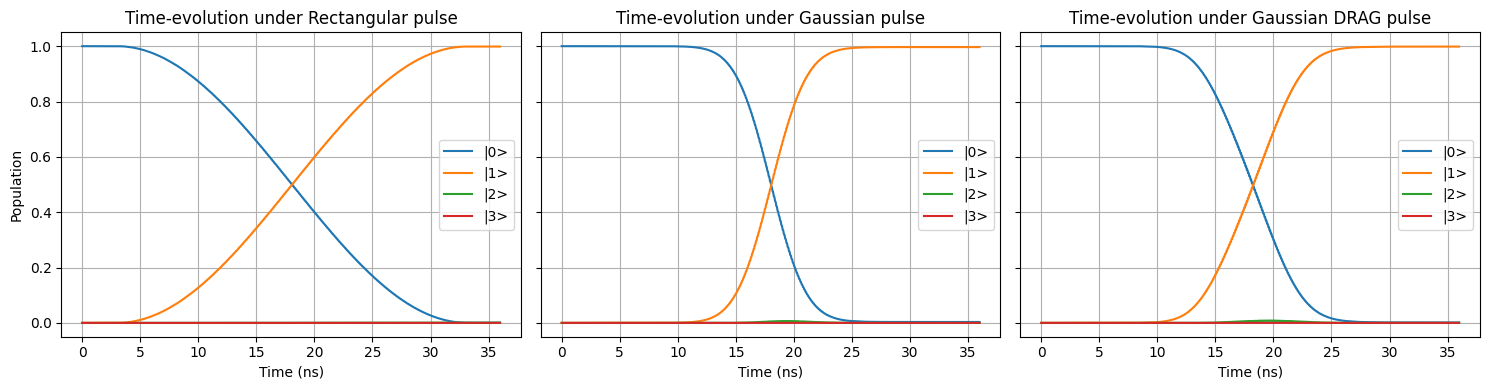

In [9]:
psi0 = np.zeros(K, dtype=complex)
psi0[0] = 1.0
T = 30e-9
anharmonicity = transition_frequency(np.diag(Htransmon), transition="01") - transition_frequency(np.diag(Htransmon), transition="12")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# Rectangular
pop, times = time_evolution(
    psi0=psi0, H0=Htransmon, G=G4,
    duration=T*1.2, T=T, A=17e6, tol=1e-8,
    env="rect", detuning=0e6
)
pops = np.abs(pop)**2
times_ns = np.array(times) * 1e9
for i in range(4):
    axes[0].plot(times_ns, pops[:, i], label=f"|{i}>")
axes[0].set_title("Time-evolution under Rectangular pulse")
axes[0].set_xlabel("Time (ns)")
axes[0].set_ylabel("Population")
axes[0].legend()
axes[0].grid()

# Gaussian
pop, times = time_evolution(
    psi0=psi0, 
    H0=Htransmon, 
    G=G4,
    duration=T*1.2, 
    T=T, A=17e6, 
    tol=1e-8,
    env="gaussian", 
    sigma=T/8, 
    detuning=0e6
)
pops = np.abs(pop)**2
times_ns = np.array(times) * 1e9
for i in range(4):
    axes[1].plot(times_ns, pops[:, i], label=f"|{i}>")
axes[1].set_title("Time-evolution under Gaussian pulse")
axes[1].set_xlabel("Time (ns)")
axes[1].legend()
axes[1].grid()

# Gaussian DRAG
pop, times = time_evolution(
    psi0=psi0, 
    H0=Htransmon, 
    G=G4,
    duration=T*1.2, 
    T=T, A=17e6, 
    tol=1e-8,
    env="gaussian_drag", 
    sigma=T/8, 
    beta=-1/anharmonicity, 
    detuning=0e6
)
pops = np.abs(pop)**2
times_ns = np.array(times) * 1e9
for i in range(4):
    axes[2].plot(times_ns, pops[:, i], label=f"|{i}>")
axes[2].set_title("Time-evolution under Gaussian DRAG pulse")
axes[2].set_xlabel("Time (ns)")
axes[2].legend()
axes[2].grid()

plt.tight_layout()
plt.show()

In all three cases the transmon starts in $|0\rangle$, reaches an approximately equal superposition of $|0\rangle$ and $|1\rangle$ at half the pulse duration (consistent with a Rabi oscillation), and ends near fully in $|1\rangle$ - a successful $\pi$-pulse. A small population in $|2\rangle$ is visible in all pulses, indicating leakage during the drive. The rectangular pulse shows the most leakage, as expected from its high frequency components from its discontinuities.

### Validate solver against scipy 'solve_ivp' function

Let us do a quick check that our solver is working correctly with the sufficient precision by comparing its performance against the scipy library's implementation of the RK8 method. 

In [10]:
from scipy.integrate import solve_ivp

psi0 = np.zeros(K, dtype=complex)
psi0[0] = 1.0

T = 30e-9
duration = 36e-9
A = 17e6

sigma = T / 8
w01 = transition_frequency(np.diag(Htransmon), "01")
envelope = make_gaussian(duration, T, sigma, area_normalized=True)

def H(t):
    return Htransmon + A * np.cos(2 * np.pi * w01 * t) * envelope(t) * G4

def f(t, psi):
    return -1j * 2 * np.pi * (H(t) @ psi)

# RK78 solution
psi_rk, times = solve_ode_rk78(
    start=0,
    end=duration,
    initial_state=psi0,
    f=f,
    error_tolerance=1e-8,
)

psi_rk_final = np.array(psi_rk[-1])

# scipy reference solution
ref = solve_ivp(
    f,
    t_span=(0, duration),
    y0=psi0,
    method="DOP853", # scipy implementation of RK8
    rtol=1e-10,
    atol=1e-12,
)

psi_scipy_final = ref.y[:, -1]
final_error = np.linalg.norm(psi_rk_final - psi_scipy_final)

print("RK78 validation against scipy.solve_ivp")
print("----------------------------------------")
print(f"Final-state difference: {final_error:.3e}")
print(f"RK78 final P1:   {np.abs(psi_rk_final[1])**2:.6f}")
print(f"SciPy final P1:  {np.abs(psi_scipy_final[1])**2:.6f}")

RK78 validation against scipy.solve_ivp
----------------------------------------
Final-state difference: 6.564e-06
RK78 final P1:   0.996703
SciPy final P1:  0.996702


# <a id='sim'></a>[4&nbsp;&nbsp;&nbsp;Simulation and Results](#cont)

We now evaluate each pulse on peak fidelity and robustness. Fidelity is defined as the $|1\rangle$ population at the end of the drive, $F = P_1(T)$ — a value of 1 means a perfect X gate. Robustness measures how much the amplitude or drive frequency can deviate from their optimal values before fidelity drops below a threshold (here 99%).

Each pulse is simulated over a grid of 200 amplitudes ($0$–$60$ MHz) and 51 detunings ($-40$–$40$ MHz) around the optimal point, with pulse width fixed at 30 ns. The detuning $\delta_d = \omega_d - \omega_{01}$ represents a mismatch between the drive frequency and the qubit transition frequency, as would occur in an experiment from noise in control electronics or miscalibration. The simulations are computationally expensive (several hours for the full sweep), but precomputed results are provided and loaded below.

In [ ]:
# EXPENSIVE simulation -- load the computed simulation results after this block

duration = 36e-9
T = 30e-9
Amps = np.linspace(start=0e6, stop=60e6, num=200)
ds = np.linspace(start=-40e6, stop=40e6, num=51)
ground_state = [1, 0, 0, 0]

# rectangular
pops_rect = np.zeros((len(Amps), len(ds), 4))
for i, amp in enumerate(Amps):
    for j, d in enumerate(ds):
        psi, times = time_evolution(
            duration=duration,
            psi0=ground_state, 
            H0=Htransmon, 
            G=G4, 
            T=T, 
            A=amp, 
            detuning=d, 
            env="rect"
        )
        pops_rect[i, j, :] = np.abs(psi[-1])**2

# gaussian
pops_gauss = np.zeros((len(Amps), len(ds), 4))
for i, amp in enumerate(Amps):
    for j, d in enumerate(ds):
        psi, times = time_evolution(
            psi0=ground_state, 
            H0=Htransmon, 
            G=G4, 
            duration=duration,
            T=T, 
            A=amp, 
            detuning=d, 
            env="gaussian",
            sigma=T/8  # 4 standard deviations from center to edge that balances truncation error and pulse narrowness
        )
        pops_gauss[i, j, :] = np.abs(psi[-1])**2   


# gaussian DRAG
pops_drag = np.zeros((len(Amps), len(ds), 4))
for i, amp in enumerate(Amps):
    for j, d in enumerate(ds):
        psi, times = time_evolution(
            psi0=ground_state, 
            H0=Htransmon, 
            G=G4, 
            T=T, 
            duration=duration,
            A=amp, 
            detuning=d, 
            env="gaussian_drag",
            sigma=T/8,  # 4 standard deviations from center to edge that balances truncation error and pulse narrowness
            beta=-1/anharmonicity  # first-order DRAG correction that cancels |1>->|2> leakage
        )
        pops_drag[i, j, :] = np.abs(psi[-1])**2  


# # np.savez_compressed(
# #     "transmon_simulation_results.npz",
# #     amps=Amps,
# #     ds=ds,
# #     pops_rect=pops_rect,
# #     pops_gauss=pops_gauss,
# #     pops_drag=pops_drag
# # )

In [16]:
#Load precomputed results
loaded_data = np.load("transmon_simulation_results.npz")
Amps = loaded_data["amps"]
ds = loaded_data["ds"]
pops_rect = loaded_data["pops_rect"]
pops_gauss = loaded_data["pops_gauss"]
pops_drag = loaded_data["pops_drag"]

Text(0.5, 0, 'Detuning (MHz)')

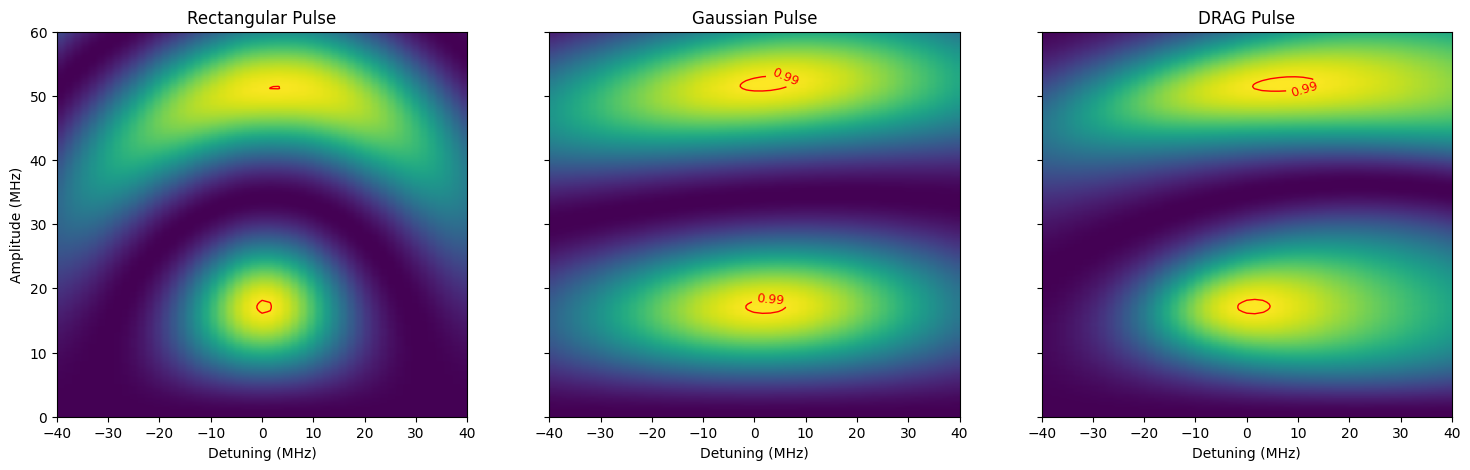

In [17]:
# excited-state populations
pop1_rect = pops_rect[:, :, 1]
pop1_gauss = pops_gauss[:, :, 1]
pop1_drag = pops_drag[:, :, 1]

extent = [
    ds[0] / 1e6,
    ds[-1] / 1e6,
    Amps[0] / 1e6,
    Amps[-1] / 1e6
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
# Rectangular
im0 = axes[0].imshow(pop1_rect, aspect="auto", origin="lower", extent=extent)
ct0 = axes[0].contour(pop1_rect, levels=[0.99], colors="red", linewidths=1.0, extent=extent, origin="lower")
axes[0].clabel(ct0, fmt="0.99", fontsize=9, inline=True)
axes[0].set_title("Rectangular Pulse")
axes[0].set_xlabel("Detuning (MHz)")
axes[0].set_ylabel("Amplitude (MHz)")

# Gaussian
im1 = axes[1].imshow(pop1_gauss, aspect="auto", origin="lower", extent=extent)
ct1 = axes[1].contour(pop1_gauss, levels=[0.99], colors="red", linewidths=1.0, extent=extent, origin="lower")
axes[1].clabel(ct1, fmt="0.99", fontsize=9, inline=True)
axes[1].set_title("Gaussian Pulse")
axes[1].set_xlabel("Detuning (MHz)")

# DRAG
im2 = axes[2].imshow(pop1_drag, aspect="auto", origin="lower", extent=extent)
ct2 = axes[2].contour(pop1_drag, levels=[0.99], colors="red", linewidths=1.0, extent=extent, origin="lower")
axes[2].clabel(ct2, fmt="0.99", fontsize=9, inline=True)
axes[2].set_title("DRAG Pulse")
axes[2].set_xlabel("Detuning (MHz)")

Each plot shows two bright lobes: the lower-amplitude one is the $\pi$-rotation (X gate) and the upper one is a $3\pi$-rotation — the first two Rabi oscillations. At even higher amplitudes, $5\pi$, $7\pi$, ... lobes would appear. We focus on the $\pi$-lobe. The red contour marks the $F = 0.99$ boundary, with a larger enclosed area indicating a more robust pulse.

By inspection, the rectangular pulse has the smallest high-fidelity region. The Gaussian and DRAG pulses both show larger areas, consistent with their narrower frequency spectrum,. The DRAG lobe is slightly asymmetric toward positive detunings, most likely a consequence of the imaginary derivative term shifting the effective drive frequency.

In [18]:
max_fid_rect = np.max(pop1_rect[:100, :]) # we only consider the lower half of amplitudes to isolate the pi-lobe
max_fid_gauss = np.max(pop1_gauss[:100, :])
max_fid_drag = np.max(pop1_drag[:100, :])


print("Maximum fidelity of rectangular pulse: ", max_fid_rect)
print("Maximum fidelity of gaussian pulse: ", max_fid_gauss)
print("Maximum fidelity of gaussian drag pulse: ", max_fid_drag)
print("-" * 100)

datasets = {
    "Rectangular": pop1_rect[:100, :],
    "Gaussian": pop1_gauss[:100, :],
    "DRAG": pop1_drag[:100, :],
}

for name, P1 in datasets.items():

    max_fidelity = np.max(P1*100)

    i_opt, j_opt = np.unravel_index(
        np.argmax(P1),
        P1.shape
    )
    best_amp = Amps[i_opt]
    best_detuning = ds[j_opt]

    print(f"{name} pulse")
    print(f"  max fidelity  : {max_fidelity:.6f}%")
    print(f"  best amplitude: {best_amp/1e6:.3f} MHz")
    print(f"  best detuning : {best_detuning/1e6:.3f} MHz")
    print()



Maximum fidelity of rectangular pulse:  0.9985047725969004
Maximum fidelity of gaussian pulse:  0.9996556072295618
Maximum fidelity of gaussian drag pulse:  0.9998079201332383
----------------------------------------------------------------------------------------------------
Rectangular pulse
  max fidelity  : 99.850477%
  best amplitude: 17.186 MHz
  best detuning : 0.000 MHz

Gaussian pulse
  max fidelity  : 99.965561%
  best amplitude: 17.186 MHz
  best detuning : 1.600 MHz

DRAG pulse
  max fidelity  : 99.980792%
  best amplitude: 17.186 MHz
  best detuning : 1.600 MHz



In [19]:
def robustness_region(pop1, Amps, ds, threshold=0.99):
    """
    Compute the robustness region above a fidelity threshold.

    Parameters
    ----------
    fidelities : np.ndarray
        Fidelity values over parameter space.
    threshold : float, optional
        Fidelity threshold defining robustness.

    Returns
    -------
    float
        Area of the robustness region.
    """
    dA = (Amps[1] - Amps[0]) / 1e6
    dd = (ds[1] - ds[0]) / 1e6
    return (pop1 >= threshold).sum() * dA * dd

for name, P1 in datasets.items():
    area = robustness_region(P1, Amps[:100], ds)
    print(f"{name} pulse:  region area >99% : {area:.2f} MHz²")

Rectangular pulse:  region area >99% : 4.82 MHz²
Gaussian pulse:  region area >99% : 13.03 MHz²
DRAG pulse:  region area >99% : 11.10 MHz²


The Gaussian pulse has the largest high-fidelity area overall, making it the most robust against combined amplitude and detuning errors. As expected, the rectangular pulse is the least robust as its sharp edges produce high-frequency components that drive unwanted transitions. The DRAG pulse has slightly lower robustness than the Gaussian but achieves higher peak fidelity, making it the better choice when simply the highest possible achievable gate fidelity is the objective.

# <a id='conc'></a>[5&nbsp;&nbsp;&nbsp;Conclusions](#cont)

We simulated an X gate on a transmon qubit using rectangular, Gaussian, and Gaussian DRAG pulses to evaluate their peak fidelity and robustness. Time evolution was computed with an implemented RK78 solver over a grid of amplitudes and detunings to map out each pulse's high-fidelity region. The main simulation results are summarized below:

| Pulse Type | Maximum Fidelity | Leakage to ∣2⟩ | Robustness to Amplitude Errors |
|-------------|------------------|----------------------------|--------------------------------|
| Rectangular | High near optimal amplitude | Largest leakage | Narrow robustness region |
| Gaussian | High | Reduced leakage | Largest robustness region | Smooth pulse envelope |
| Gaussian DRAG | Highest overall | Smallest leakage | Moderate robustness region |

All three pulses successfully implement the X gate, but with clear differences in quality. The rectangular pulse has the lowest fidelity and smallest high-fidelity region. Its discontinuous edges introduce unwanted high-frequency components that drives leakage into $|2\rangle$. The Gaussian pulse improves the rectangular pulse in both aspects, by its smoother envelope, and achieves the largest high-fidelity area, making it the most robust against calibration errors. The Gaussian DRAG pulse achieves the highest peak fidelity by actively suppressing leakage by its imaginary derivative term. This comes at a slight cost to robustness compared to the normal Gaussian.

In practice, the best choice depends on the goal: if robustness to frequency drift and amplitude noise is the priority, the Gaussian pulse is the best choice. However, if the system is very well calibrated and can produce very exact pulses, the DRAG is the better option because it has the highest maximal X-gate fidelity.

The custom RK78 solver was validated against SciPy’s DOP853 integrator. The final-state populations agreed to six decimal places, indicating that the RK78 implementation was sufficiently accurate for the fidelity comparisons performed in this project.

Future work could extend the model by including decoherence effects such as relaxation and dephasing by modeling the qubit with the Lindblad master equation. Furthermore, the simulations could be expanded to investigate how optimizing the pulse parameters such as sigma and beta can improve the performance of the gaussian and DRAG pulses. 



## Sources:

[1] : J. Koch, T. M. Yu, J. Gambetta, A. A. Houck, D. I. Schuster, J. Majer, A. Blais, M. H. Devoret, S. M. Girvin, and R. J. Schoelkopf, “Charge-insensitive qubit design derived from the Cooper pair box,” *PhysicalReview A*, vol. 76, no. 4, p. 042319, Oct. 2007.

[2] : Quantum Systems Architecture, “The DRAG Pulse,” QSysArch, 2024. [Online]. Available: https://qsysarch.com/posts/the-drag-pulse/. [Accessed: May 22, 2026].

[3] : “Runge–Kutta methods,” *Wikipedia*, Wikimedia Foundation. [Online]. Available: https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods. [Accessed: May 22, 2026].

[4] :  M. B. Zaman, “Runge-Kutta-Fehlberg RKF78,” *MATLAB Central File Exchange*, MathWorks, 2016. [Online]. Available: https://www.mathworks.com/matlabcentral/fileexchange/61130-runge-kutta-fehlberg-rkf78. [Accessed: May 22, 2026].


